In [2]:
# Librerias necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import parametros as p
from kpis import *

In [3]:
# Funciones necesarias para preprocesamiento de datos
def agregar_filas_intermedias(df, escala):
    tl = df.copy()
    tiene_requerimiento_inicial = "requerimiento_inicial" in tl.columns

    def add_event_order(df):
        if "orden" not in df.columns:
            df = df.copy()
            df["orden"] = df.groupby("ID").cumcount() + 1
        return df
    
    # Agrego orden de eventos
    tl = add_event_order(tl)

    tl.sort_values(by=["ID", "orden"], inplace=True)
    if escala != 12:
        tl["TI"] = tl["TI"]*12
        tl["TF"] = tl["TF"]*12

    # Agrego LOS a cada fila y reordeno
    tl["LOS"] = (tl["TF"] - tl["TI"])
    if tiene_requerimiento_inicial:
        tl = tl[["ID", "MS_GRD", "UBICACIÓN", "TI", "TF", "LOS", "HOSPITAL", "UNIDAD", "orden", "requerimiento_inicial"]]
    else:
        tl = tl[["ID", "MS_GRD", "UBICACIÓN", "TI", "TF", "LOS", "HOSPITAL", "UNIDAD", "orden"]]

    # Lista para guardar filas nuevas
    new_rows = []

    # Recorrer filas consecutivas
    for i in range(len(tl) - 1):
        row_current = tl.iloc[i]
        row_next = tl.iloc[i + 1]

        # Verificar condiciones
        same_id = row_current['ID'] == row_next['ID']
        same_ms = row_current['MS_GRD'] == row_next['MS_GRD']
        time_gap = row_current['TF'] < row_next['TI']
        time_gap_cero = row_current['TF'] == row_next['TI']
        same_hospital = row_current['HOSPITAL'] == row_next['HOSPITAL']
        
        if tiene_requerimiento_inicial:
            if same_id and same_ms and time_gap:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': row_current['UNIDAD'],
                    'orden': row_current['orden'] + 0.1,  # Ajustar el orden
                    'requerimiento_inicial': row_current['requerimiento_inicial']
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
            
            if same_id and same_ms and time_gap_cero and not same_hospital:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': "En movimiento",
                    'orden': row_current['orden'] + 0.1,  # Ajustar el orden
                    'requerimiento_inicial': row_current['requerimiento_inicial']
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
        else:
            if same_id and same_ms and time_gap:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': row_current['UNIDAD'],
                    'orden': row_current['orden'] + 0.1  # Ajustar el orden
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción
            
            if same_id and same_ms and time_gap_cero and not same_hospital:
                # Crear fila intermedia
                new_row = {
                    'ID': row_current['ID'],
                    'MS_GRD': row_current['MS_GRD'],
                    'UBICACIÓN': f"{row_current['UBICACIÓN']} -> {row_next['UBICACIÓN']}",
                    'TI': row_current['TF'],
                    'TF': row_next['TI'],
                    'LOS': row_next['TI'] - row_current['TF'],
                    'HOSPITAL': row_current['HOSPITAL'],
                    'UNIDAD': "En movimiento",
                    'orden': row_current['orden'] + 0.1  # Ajustar el orden
                }
                new_rows.append((i + 1, new_row))  # guardar con índice de inserción

    # Lista para guardar todas las filas nuevas (dicts)
    new_rows_list = [fila[1] for fila in new_rows]

    # Convertir todo a un DataFrame una sola vez
    new_rows_df = pd.DataFrame(new_rows_list)

    # Concatenar en una sola pasada
    tl = pd.concat([tl, new_rows_df], ignore_index=True)

    # Reordenar filas para meter filas entremedio
    tl = tl.sort_values(by=["ID", "orden"])

    # Resetear index para que se vea ordenado
    tl_1 = tl.reset_index(drop=True)

    # Ya ordenado elimino la columna orden
    tl_1.drop(columns=["orden"], inplace=True)

    return tl_1

def add_operational_costs(df):
    df = df.copy()  # avoid mutating original

    # Define transfer transitions
    traslados = {
        'Hospital_1_ED -> Hospital_2_ED',
        'Hospital_1_ED -> Hospital_3_ED',
        'Hospital_2_ED -> Hospital_1_ED',
        'Hospital_2_ED -> Hospital_3_ED',
        'Hospital_3_ED -> Hospital_1_ED',
        'Hospital_3_ED -> Hospital_2_ED'
    }

    # Costo DER WL
    if 'requerimiento_inicial' in df.columns:
        df["COSTO DER WL"] = df.apply(
            lambda x: p.dict_costo_derivar_wl[x["MS_GRD"]][x["requerimiento_inicial"]]
            if x["UBICACIÓN"] == "WL_WL -> PS_PS" else 0,
            axis=1
        )
    else:
        df["COSTO DER WL"] = df.apply(
            lambda x: (
                sum(p.dict_costo_derivar_wl[x["MS_GRD"]][u] for u in [1, 2, 3]) / 3
                if x["UBICACIÓN"] == "WL_WL -> PS_PS" else 0
            ),
            axis=1
        )

    # Costo DER ED
    if 'requerimiento_inicial' in df.columns:
        df["COSTO DER ED"] = df.apply(
            lambda x: p.dict_costo_derivar_ed[p.dict_hospitales[x["HOSPITAL"]]][x["MS_GRD"]][x["requerimiento_inicial"]]
            if x["UBICACIÓN"] == f"{x['HOSPITAL']}_ED -> PS_PS" else 0,
            axis=1
        )
    else:
        df["COSTO DER ED"] = df.apply(
            lambda x: (
                sum(p.dict_costo_derivar_ed[p.dict_hospitales[x["HOSPITAL"]]][x["MS_GRD"]][u] for u in [1, 2, 3]) / 3
                if x["UBICACIÓN"] == f"{x['HOSPITAL']}_ED -> PS_PS" else 0
            ),
            axis=1
        )

    # Costo TRASLADO
    def parse_hospital_number(hospital_str):
        return int(hospital_str.split("_")[1])

    if 'requerimiento_inicial' in df.columns:
        df["COSTO TRASLADO"] = df.apply(
            lambda x: (
                p.dict_costo_traslado[
                    parse_hospital_number(x["UBICACIÓN"].split(" -> ")[0])
                ][
                    parse_hospital_number(x["UBICACIÓN"].split(" -> ")[1])
                ][x["MS_GRD"]][
                    x["requerimiento_inicial"]
                ]
                if x["UBICACIÓN"] in traslados else 0
            ),
            axis=1
        )
    else:
        def costo_promedio_traslado(x):
            if x["UBICACIÓN"] not in traslados:
                return 0
            h1 = parse_hospital_number(x["UBICACIÓN"].split(" -> ")[0])
            h2 = parse_hospital_number(x["UBICACIÓN"].split(" -> ")[1])
            costos = [p.dict_costo_traslado[h1][h2][x["MS_GRD"]][u] for u in [1, 2, 3]]
            return sum(costos) / 3

        df["COSTO TRASLADO"] = df.apply(costo_promedio_traslado, axis=1)
        
        

    return df

def add_waiting_costs(df):
    df = df.copy()

    def calcular_costo_espera(row):
        drg = row["MS_GRD"]
        los = row["LOS"] / 12 # Convertir a ciclos
        unidad = row.get("requerimiento_inicial", None)
        ubicacion = row["UBICACIÓN"]
        hospital_nombre = row["HOSPITAL"]
        hospital = p.dict_hospitales.get(hospital_nombre)

        # 1. Paciente en WL_WL (esperando en lista)
        if row["HOSPITAL"] == "WL" and ubicacion == "WL_WL":
            if unidad is not None:
                return p.dict_costo_espera_wl[drg][unidad] * los
            else:
                costos = [p.dict_costo_espera_wl[drg][u] for u in [1, 2, 3]]
                return sum(costos) / 3 * los

        # 2. Paciente en GA o ED con LOS > 0
        elif row["UNIDAD"] in {"GA", "ED"} and los > 0:
            source = p.dict_costo_espera_ga if row["UNIDAD"] == "GA" else p.dict_costo_espera_ed
            if unidad is not None:
                return source[hospital][drg][unidad] * los
            else:
                costos = [source[hospital][drg][u] for u in [1, 2, 3]]
                return sum(costos) / 3 * los

        # 3. Paciente hospitalizado y bloqueado
        elif row["UNIDAD"] in {"OR", "ICU", "SDU_WARD"} and "->" in ubicacion and los > 0:
            try:
                origen_str, destino_str = ubicacion.split(" -> ")
                unidad_actual = "_".join(origen_str.split("_")[2:])
                unidad_requerida = "_".join(destino_str.split("_")[2:])
                return p.dict_costo_espera_hospitalizado[hospital][drg][p.dict_unidades[unidad_actual]][p.dict_unidades[unidad_requerida]] * los
            except Exception:
                return 0  # fallback in case of malformed UBICACION
        return 0

    df["COSTO ESPERA"] = df.apply(calcular_costo_espera, axis=1)
    return df

In [ ]:
# ldf = pd.read_csv("log original/log original.csv", sep=",")
sdf = pd.read_csv("resultados simulacion/modelo_base_a_mi_modelo.csv", sep=",")

# Agregar filas intermedias
# ldf = agregar_filas_intermedias(ldf, 12)
sdf = agregar_filas_intermedias(sdf, 1)

# Agregar costos operacionales
# ldf = add_operational_costs(ldf)
sdf = add_operational_costs(sdf)

# Agregar costos de espera
# ldf = add_waiting_costs(ldf)
sdf = add_waiting_costs(sdf)

# Para no tener que correr lo de arriba cada vez, guardo los resultados
# ldf.to_csv("resultados modificados/log_original.csv", index=False)
sdf.to_csv("resultados modificados/log_simulacion.csv", index=False)

In [ ]:
sdf = pd.read_csv("resultados simulacion/modelo_base_a_mi_modelo.csv", sep=",")
sdf = agregar_filas_intermedias(sdf, 1)
sdf = add_operational_costs(sdf)
sdf = add_waiting_costs(sdf)
sdf.to_csv("resultados modificados/log_simulacion.csv", index=False)

In [3]:
ldf = pd.read_csv("resultados modificados/log_original.csv", sep=",")
sdf = pd.read_csv("resultados modificados/log_simulacion.csv", sep=",")

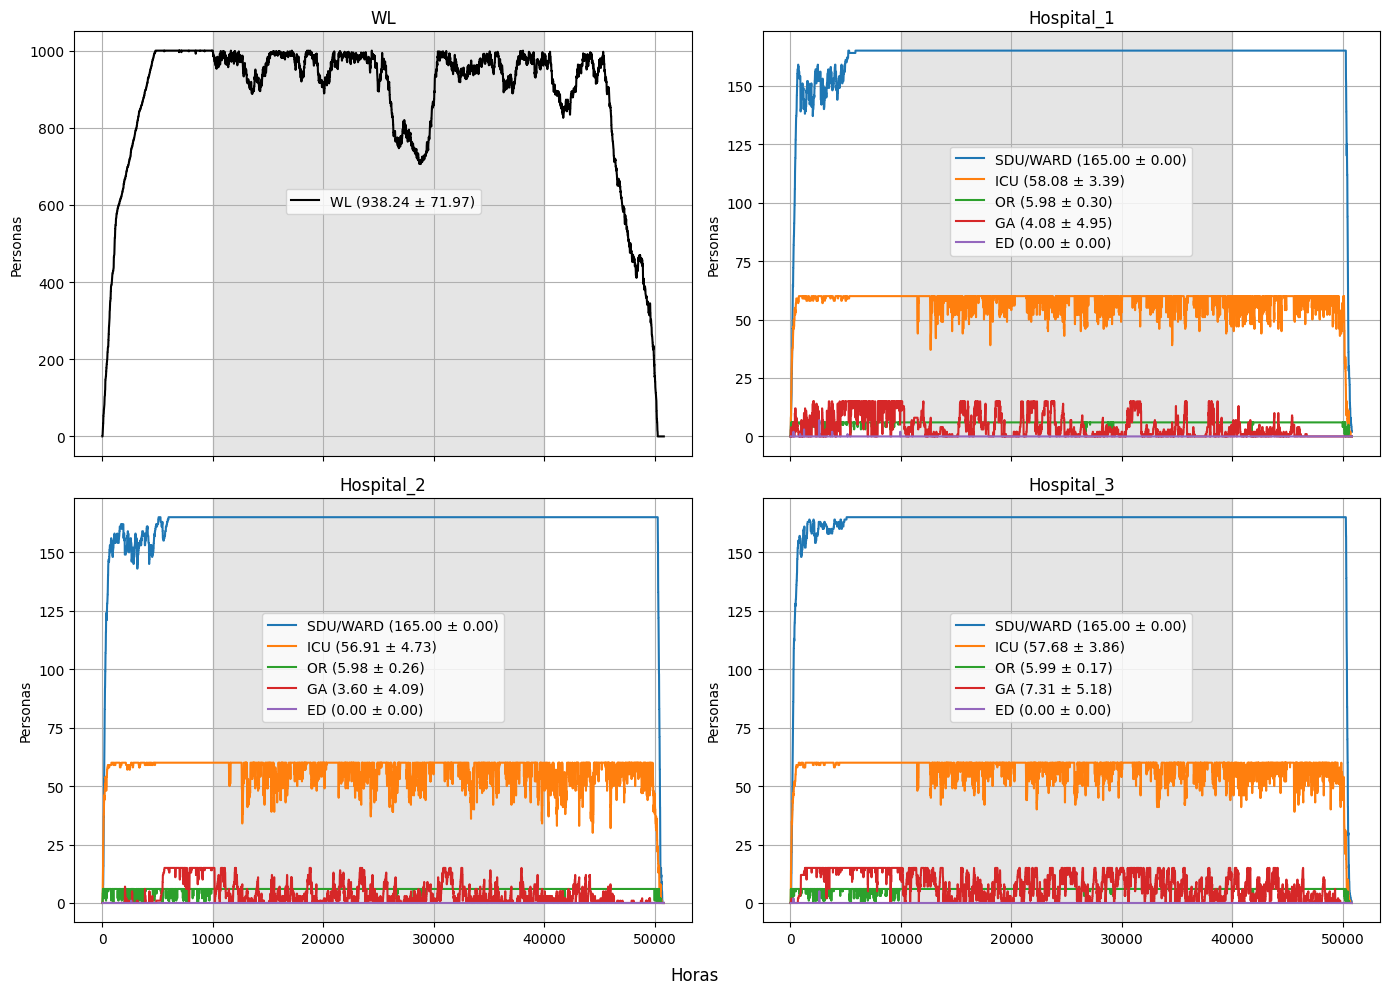

{'LOS_hospitalizado': {'por_hospital_y_unidad': {'Hospital_1': {'ED': 0.0,
    'GA': 11.55,
    'ICU': 67.65,
    'OR': 13.82,
    'SDU_WARD': 195.4},
   'Hospital_2': {'ED': 0.0,
    'GA': 7.59,
    'ICU': 63.24,
    'OR': 13.6,
    'SDU_WARD': 186.11},
   'Hospital_3': {'ED': 0.0,
    'GA': 17.28,
    'ICU': 66.4,
    'OR': 13.64,
    'SDU_WARD': 192.53}},
  'promedio_por_hospital': {'Hospital_1': 248.23,
   'Hospital_2': 256.59,
   'Hospital_3': 259.27},
  'promedio_por_unidad': {'ED': 0.0,
   'GA': 11.98,
   'ICU': 65.73,
   'OR': 13.68,
   'SDU_WARD': 191.27}},
 'LOS_lista_espera': 798.35,
 'costo_diario_promedio': {'social': 8515.35,
  'derivaciones_wl': 218.89,
  'derivaciones_ed': 2677.78,
  'traslados': 86.29,
  'operativo': 2982.97,
  'total': 11498.32},
 'costo_promedio_paciente': {'costo_social_promedio': 266.32,
  'costo_operativo_promedio': 93.29,
  'costo_total_promedio': 359.62},
 'tasa_entrada_vs_salida': {'entradas_wl_por_ciclo': 16.05,
  'entradas_ed_por_ciclo': 15.6

In [5]:
kpis_ldf = {}
kpis_sdf = {}

# Calcular KPIs original
# calcular_kpis(ldf)
# calcular_kpis(ldf, show_plot=True)

# Calcular KPIs simulación
# calcular_kpis(sdf)
calcular_kpis(sdf, show_plot=True)